# Example: Multiplicative Weights Algorithm for Market Mood Prediction
In this example, we will implement the Multiplicative Weights Algorithm (MWA) for market mood prediction. The MWA is an online learning algorithm that adjusts the weights of different expert models based on their performance over time.

> __Learning Objectives__
> 
> By the end of this example, you should be able to:
> * __Implement the Multiplicative Weights Algorithm__ to select among expert models (Hidden Markov Model states) by maintaining and updating probability distributions over experts based on their prediction accuracy.
> * __Evaluate expert performance__ by comparing predicted market moods against true states and computing costs that penalize incorrect predictions while rewarding correct ones.
> * __Analyze weight convergence__ to understand which expert models (market regimes) the MWA identifies as most reliable for market mood prediction over time.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [3]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [VLQuantitativeFinancePackage.jl documentation](https://github.com/varnerlab/VLQuantitativeFinancePackage.jl). 

### Data, Models and Constants
Before we implement the MWA, we need to load up some models and data. First, let's load the HMM model that we estimated using historical data (2014 - 2024). To start, we specify the `path_to_save_file::String` variable:

In [6]:
path_to_save_file = joinpath(_PATH_TO_DATA,"HMM-WJ-SPY-N-100-daily-aggregate.jld2");

Next, load the [`HDF5` binary file](https://en.wikipedia.org/wiki/Hierarchical_Data_Format) using [the `load(...)` function from JLD2.jl](https://github.com/JuliaIO/JLD2.jl.git). This loads the saved data into the `saved_state_dict::Dict{String, Any}` variable.

In [8]:
saved_state_dict = load(path_to_save_file)

Dict{String, Any} with 11 entries:
  "risk_free_rate"          => 0.043
  "model"                   => MyHiddenMarkovModel([1, 2, 3, 4, 5, 6, 7, 8, 9, …
  "decode"                  => Dict{Int64, Normal}(5=>Normal{Float64}(μ=-3.3565…
  "encoded_archive_with_ju… => [53 72 … 82 92; 93 82 … 80 5; … ; 14 67 … 87 13;…
  "insampledataset"         => [-0.62754, 0.839626, 0.162992, -0.0111337, 0.257…
  "jump_model"              => MyHiddenMarkovModelWithJumps([1, 2, 3, 4, 5, 6, …
  "encoded_archive"         => [48 29 … 28 33; 42 10 … 10 68; … ; 18 37 … 39 77…
  "number_of_states"        => 100
  "in_sample_decoded_archi… => [0.202562 0.962389 … 1.56531 2.7557; 2.94573 1.6…
  "stationary"              => Categorical{Float64, Vector{Float64}}(…
  "in_sample_decoded_archi… => [0.0753184 -0.675607 … -0.759002 -0.470222; -0.1…

Next, let's set some constants that we will use in the MWA implementation. See the comment next to each constant for additional information, e.g., units, permissible values, etc.

In [10]:
number_of_hidden_states = saved_state_dict["number_of_states"];
number_of_experts = number_of_hidden_states; # in this case, each hidden state is an "expert"
T = 10*252; # number of rounds to simulate
η = 0.5; # learning rate (0 < η ≤ 1/2)
π̄ = saved_state_dict["stationary"]; # stationary distribution
mymodel = saved_state_dict["model"]; # Which model do we use? 
γ = 0.1; # split for probability

What do we get if we sample the stationary distribution $\bar{\pi}$ of the HMM model?

In [12]:
rand(π̄) # initial weights

76

Next, we define a `world(...)` function that simulates the true market state using the Hidden Markov Model. 

> __What does the `world(...)` function do?__ The `world(...)` function takes a model of type `Union{MyHiddenMarkovModel, MyHiddenMarkovModelWithJumps}` and an initial state `sₒ::Int64` and returns the sequence of hidden states over `number_of_steps::Int64` time steps. The `world(...)` function serves as the environment that reveals the true market mood after each prediction round.

In [14]:
function world(model::Union{MyHiddenMarkovModel, MyHiddenMarkovModelWithJumps}, sₒ::Int; number_of_steps::Int = 1)
    tmp = model(sₒ, number_of_steps);
    return tmp
end

world (generic function with 1 method)

Let's generate a few samples from the world model to see how it works:

In [62]:
world(mymodel, 33, number_of_steps = 2)

2×2 Matrix{Int64}:
 33  0
 77  0

___

## Task 1: Implement the MWA learning algorithm
In this task, we will implement the MWA learning algorithm for market mood prediction. The MWA algorithm maintains a set of weights for each expert model and updates these weights based on the performance of the models over time.

> __What is going on here?__ The code block below implements the MWA algorithm over `T::Int64` rounds. At each round `t`, we: (1) normalize the weights to form a probability distribution `p::Array{Float64,1}` over experts, (2) select the expert `i::Int64` with the highest probability, (3) simulate the true market state using the `world(...)` function, (4) compute the cost `m::Float64` where $m = -1$ if the prediction is correct and $m = +1$ if incorrect, (5) update the selected expert's weight using the rule $w_{i}^{(t+1)} = w_{i}^{(t)} \cdot (1 - \eta \cdot m)$, and (6) store both the predicted and true states. 

The algorithm returns the state history `S::Array{Int64,2}` and the weight history `W::Array{Float64,2}`.

In [72]:
S, W = let

    # 
    weights = Array{Float64, 2}(undef, T+1, number_of_experts);
    weights[1, :] .= T; # everyone starts with equal weight
    s = rand(π̄); # initial state from the stationary distribution
    states = Array{Int, 2}(undef, T,2); # to store the true states over time

    # main loop -
    for t in 1:T
                
        # compute the probability distribution over experts for time t
        up = weights[t, :] / sum(weights[t, :]);
        p = (1 - γ) * up .+ (γ / number_of_experts); # probability distribution over experts with exploration factor
        i = argmax(p); # select the expert with the highest probability of success
        pᵢ = p[i]; # probability of success for the selected expert
        
        # Simulate the true state using the world function
        result = world(mymodel, s, number_of_steps = 2); # get the true state at time t
        true_state = result[end,1]; # extract the true state
        
        # compute the cost for the selected expert -
        m = (true_state == i) ? -1.0 / pᵢ : 1.0 ; # cost is -1 if the expert is correct, 1 otherwise
        
        # update the weight of the selected expert
        weights[t+1, :] = weights[t, :]; # start with previous weights
        weights[t+1, i] = weights[t, i] * (1 - η * m); # feedback for the selected expert
        # weights[t+1, true_state] = weights[t, true_state] * (1 + η); # feedback for the true state expert

        # store the guess and the true states -
        states[t, 1] = i; # expert's guess
        states[t, 2] = true_state; # true state

        # update the state for the next round
        s = true_state;
    end
    
    states, weights; # return 
end

([1 9; 2 27; … ; 60 36; 61 4], [2520.0 2520.0 … 2520.0 2520.0; 1260.0 2520.0 … 2520.0 2520.0; … ; 0.00016557684947913953 0.00015020370483398438 … 0.00030040740966796875 0.00030040740966796875; 0.00016557684947913953 0.00015020370483398438 … 0.00030040740966796875 0.00030040740966796875])

___

## Task 2: Let's Analyze the Results
In this task, we will analyze the results of the MWA implementation. We will evaluate the performance of the MWA algorithm in predicting market moods and compare it to the performance of individual expert models.

First, let's explore the weights of the expert models over time. What is the expert with the highest weight at the end of the simulation? What does this tell us about the performance of the expert models?

In [74]:
W[end, :] |> x-> x / sum(x) |> x-> argmax(x) # normalize final weights → find expert with highest probability

62

Let's visualize the probability distribution over expert models at the end of the simulation. We filter to show only experts with probability above a threshold to identify which market regimes the MWA considers most reliable:

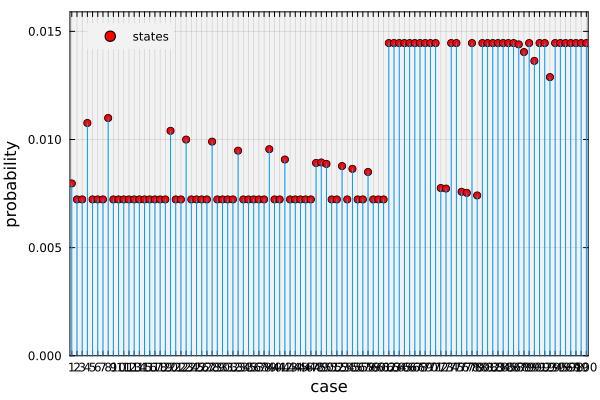

In [76]:
let
    # highlight only the largest final weights (spikes)
    final_weights = W[end, :]
    probs = final_weights ./ sum(final_weights)
    cases = collect(1:length(probs))

    threshold = 0.05 # minimum probability to keep
    top_n = min(100, length(probs))
    top_idx = sortperm(probs; rev = true)[1:top_n]
    keep = sort(union(findall(p -> p >= threshold, probs), top_idx))

    # @show keep, probs[keep]

    sel_cases = cases[keep]
    sel_probs = probs[keep]
    xmax = length(sel_cases)
    x_positions = collect(1:xmax) .* 1.4 # spread ticks to avoid overlap
    labels = string.(sel_cases)
    ymax = maximum(sel_probs) > 0 ? maximum(sel_probs) * 1.1 : 1.0

    plot(
        x_positions,
        sel_probs,
        seriestype = :sticks,
        marker = (:circle, 4, :red),
        xlabel = "case",
        ylabel = "probability",
        xticks = (x_positions, labels),
        legend = false,
        ylims = (0, ymax),
        xlims = (minimum(x_positions) - 0.5, maximum(x_positions) + 0.5),
        label="states"
    );

    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent, legend=:topleft);
end


On any given day, what do our MWA experts say is the highest probability market mood? Let's look at the state history `S::Array{Int64,2}` where the first column is the expert's prediction and the second column is the true state:

In [86]:
S[1:1110, :] # show the expert guesses vs true states from round (something) onward

1110×2 Matrix{Int64}:
  1   9
  2  27
  3  98
  4  22
  5  31
  6  14
  7  20
  8  39
  9  47
 10  25
 11  83
 12  32
 13  30
  ⋮  
 26  23
 27  16
 29  23
 30  22
 31   1
 32   2
 33  47
 34  66
 35  92
 36   6
 37  15
 38  68

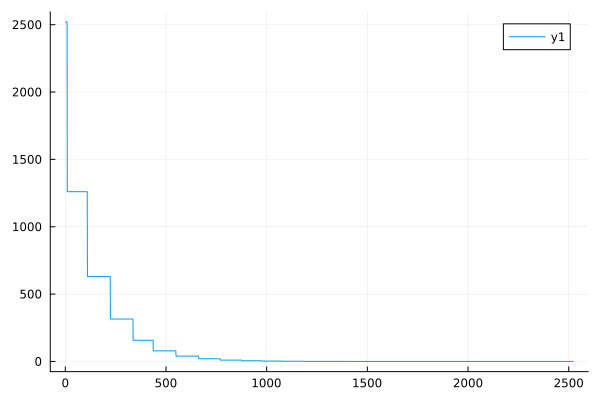

In [88]:
plot(W[:,9])

___

## Summary
This example demonstrates how the Multiplicative Weights Algorithm adapts to predict market moods by learning from expert model performance over time.

> __Key Takeaways:__
> 
> * __MWA Updates Weights Based on Performance:__ The algorithm maintains weights for each expert (HMM state) and updates them multiplicatively based on prediction accuracy. Correct predictions increase an expert's weight, while incorrect predictions decrease it.
> * __Expert Selection via Probability Sampling:__ At each round, the MWA selects the expert with the highest normalized weight. The cost function assigns $-1$ for correct predictions and $+1$ for incorrect predictions, driving weight updates toward reliable experts.
> * __Weight Convergence Reveals Market Regimes:__ Over many rounds, the weight distribution concentrates on experts that consistently predict the true market state, identifying which HMM states (market moods) are most predictable.

The MWA provides a framework for combining multiple expert models and learning which ones perform best in predicting market dynamics.
___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___